In [16]:
# --- Parse + map the dual (text+vision) outputs into tidy rows (no saving) ---

import json, re, ast
from pathlib import Path
import pandas as pd

# -----------------------------
# Canonical schema & aliases
# -----------------------------
TARGET_FIELDS = [
    "load_number",
    "pickup_location",
    "pickup_time",
    "dropoff_location",
    "dropoff_time",
    "total_rate",
    "rate_per_mile",
]

ALIASES = {
    "load_number": {
        "load number","load_number","loadnumber","load no","load#","loadnum","load",
        "ld num","ld#","lnum"
    },
    "pickup_location": {
        "pickup location","pickuplocation","origin","pu location","pu_loc","pu",
        "pu address","origin location","pickup addr","pickup point"
    },
    "pickup_time": {
        "pickup time","pickuptime","pu time","pickup date","pickup datetime","pu_time",
        "origin time","pickup at","time of pickup","pu dt"
    },
    "dropoff_location": {
        "dropoff location","drop-off location","drop_off_location","destination",
        "delivery location","drop location","do location","dropoff loc",
        "consignee","delivery addr","dest","dest location"
    },
    "dropoff_time": {
        "dropoff time","drop-off time","drop_off_time","delivery time","delivery datetime",
        "delivery date","do time","drop time","dest time","consignee time"
    },
    "total_rate": {
        "total rate","totalrate","amount","linehaul","rate total","grand total","total",
        "charge total","line haul","rate","amt"
    },
    "rate_per_mile": {
        "rate per mile","ratepermile","r/mi","r/mile","rate/mi","rpm","rate per mi",
        "per mile rate","mile rate","rate per m mile","rate per m"
    },
}

def _canon(s: str) -> str:
    """Lowercase and remove non-alphanumerics so variants match."""
    return re.sub(r"[^a-z0-9]", "", (s or "").lower())

# Precompute canonical alias lookup
ALIAS_CANON = {std: {_canon(std), *(_canon(a) for a in alts)}
               for std, alts in ALIASES.items()}

# -----------------------------
# Small Levenshtein for fuzzy key matching
# -----------------------------
def levenshtein(a: str, b: str) -> int:
    a, b = str(a), str(b)
    if a == b: return 0
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        ai = a[i-1]
        for j in range(1, n+1):
            prev2 = dp[j]
            cost = 0 if ai == b[j-1] else 1
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + cost)
            prev = prev2
    return dp[n]

def normalize_key(k: str, max_dist: int = 2):
    """
    Map an arbitrary key to one of TARGET_FIELDS using:
      1) exact canonical alias match
      2) light fuzzy match against canonical aliases (Levenshtein <= max_dist)
    """
    ck = _canon(k)
    if not ck:
        return None
    # Exact alias hit
    for std, names in ALIAS_CANON.items():
        if ck in names:
            return std
    # Fuzzy: try to catch 'drop offtime', 'ratepermille', etc.
    best = (999, None)
    for std, names in ALIAS_CANON.items():
        for ali in names:
            d = levenshtein(ck, ali)
            if d < best[0]:
                best = (d, std)
    return best[1] if best[0] <= max_dist else None

# -----------------------------
# Robust raw → dict parser
# -----------------------------
def parse_json_forgiving(raw: str):
    """
    Parse messy model output to dict:
      - strips code fences
      - normalizes quotes
      - tries json.loads / ast.literal_eval
      - falls back to extracting the *first* balanced {...} block
    """
    if raw is None:
        return None
    t = str(raw).strip()

    # remove code fences
    t = re.sub(r"^\s*```(?:json)?", "", t, flags=re.I).strip()
    t = re.sub(r"```$", "", t).strip()

    # normalize smart quotes
    t = (t.replace("“","\"").replace("”","\"")
           .replace("’","'").replace("‘","'"))

    def _try_parse(s: str):
        try:
            obj = json.loads(s)
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass
        return None

    # Try whole string first
    obj = _try_parse(t)
    if isinstance(obj, dict):
        return obj

    # Otherwise extract first {...} balanced block
    stack = 0; start = -1
    for i, ch in enumerate(t):
        if ch == "{":
            if stack == 0:
                start = i
            stack += 1
        elif ch == "}":
            if stack:
                stack -= 1
                if stack == 0 and start != -1:
                    frag = t[start:i+1]
                    obj = _try_parse(frag)
                    if isinstance(obj, dict):
                        return obj
                    # continue scanning in case another block exists
    return None


# -----------------------------
# Load + reshape the dual JSON
# -----------------------------
ROOT = Path.cwd()
DUAL_PATH = ROOT / "evaluation" / "output_ratecon_dual_raw.json"

def load_dual_json(path: Path) -> pd.DataFrame:
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    rows = []
    for rec in data:
        src = rec.get("source_image")
        e_raw = rec.get("extractor_raw") or ""
        v_raw = rec.get("vision_raw") or ""
        if e_raw:
            rows.append({"source_image": src, "llm_model": f"text:{rec.get('extractor_model','')}", "raw_json": e_raw})
        if v_raw:
            rows.append({"source_image": src, "llm_model": f"vision:{rec.get('vision_model','')}", "raw_json": v_raw})
    return pd.DataFrame(rows)

raw_df = load_dual_json(DUAL_PATH)

# -----------------------------
# Parse + map to canonical fields
# -----------------------------
def parse_and_map(df_raw: pd.DataFrame) -> pd.DataFrame:
    out = []
    for _, r in df_raw.iterrows():
        obj = parse_json_forgiving(r["raw_json"])
        fields = {k: "" for k in TARGET_FIELDS}
        key_map, leftover = {}, {}

        if isinstance(obj, dict):
            for k, v in obj.items():
                if not isinstance(k, str):
                    continue
                std = normalize_key(k, max_dist=2)
                if std:
                    fields[std] = "" if v is None else str(v).strip()
                    key_map[k] = std
                else:
                    leftover[k] = v

        out.append({
            "source_image": r["source_image"],
            "llm_model": r["llm_model"],
            "raw_json": r["raw_json"],
            "key_map": key_map,
            "unmapped_keys": list(leftover.keys()),
            **fields
        })
    return pd.DataFrame(out)

parsed_df = parse_and_map(raw_df)

# -----------------------------
# Quick sanity checks in the notebook
# -----------------------------
print("Parsed rows:", len(parsed_df))

# rows where ALL canonical fields are still empty (should be 0)
mask_all_empty = (parsed_df[TARGET_FIELDS] == "").all(axis=1)
print("Rows with all fields empty:", mask_all_empty.sum())
display(parsed_df[mask_all_empty][["source_image","llm_model","raw_json"]].head(10))

# any rows with leftover (unmapped) keys so you can expand ALIASES if needed
print("\nRows with unmapped keys:")
display(parsed_df[parsed_df["unmapped_keys"].map(len) > 0][
    ["source_image","llm_model","unmapped_keys","key_map"]
].head(20))

# take a look at a few parsed rows
display(parsed_df.head(30))


Parsed rows: 30
Rows with all fields empty: 1


,source_image,llm_model,raw_json
8,a5.jpg,text:mistral-7b,"{""load_number"": ""T-113JFVVRZ"", ""pickup_locatio..."



Rows with unmapped keys:


,source_image,llm_model,unmapped_keys,key_map


,source_image,llm_model,raw_json,key_map,unmapped_keys,load_number,pickup_location,pickup_time,dropoff_location,dropoff_time,total_rate,rate_per_mile
0,a1.jpg,text:mistral-7b,"{""load number"": ""116WQ2Q4S"", ""pickup location""...","{'load number': 'load_number', 'pickup locatio...",[],116WQ2Q4S,"IND2PLainfield,IN 46168","Sun,Aug 18,11:30 EDT","MDW5 CREST Hill,ILLINOIS 60403","Sun Aug 18,15:56 CDT","$1022,07",$5.29/mi
1,a1.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,"{\n ""load_number"": ""1116WQ2Q4S"",\n ""pickup_l...","{'load_number': 'load_number', 'pickup_locatio...",[],1116WQ2Q4S,"IND2 PLAINFIELD, IN 46168","Sun, Aug 18, 11:30 EDT","MDW5 CREST HILL, ILLINOIS 60403","Sun, Aug 18, 15:56 CDT","$1,022.07",$5.29/mi
2,a2.jpg,text:mistral-7b,"{\n""Load Number"": ""T-112K9S5H5"",\n""Pickup Loca...","{'Load Number': 'load_number', 'Pickup Locatio...",[],T-112K9S5H5,"RDG1 HAMBURG, Pennsylvania 19526","Sun, Aug 18, 01:30 EDT",DET3 PONTIĄ Fuß miejsc frü Dopo ancora È luego...,"Mon, Aug 19, 03:04 EDT",$ 847.46,$ 1.51/mi
3,a2.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,"```json\n{\n ""load_number"": ""T-112K9S5H5"",\n ...","{'load_number': 'load_number', 'pickup_locatio...",[],T-112K9S5H5,"RDG1 HAMBURG, Pennsylvania 19526","Sun, Aug 18, 01:30 EDT","DET3 PONTIAC, Michigan 48342","Mon, Aug 19, 03:04 EDT",$847.46,$1.51/mi
4,a3.jpg,text:mistral-7b,"{'Load Number': 'T-113MK9MSS', 'Pickup Locatio...","{'Load Number': 'load_number', 'Pickup Locatio...",[],T-113MK9MSS,Spot,10h 33m,"LDJ5 STATEN ISLAND,NY 10314","Sun,Aug 18,16:15 EDT",$1459.89,$2.17/mi
5,a3.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,"{\n ""load_number"": ""T-113MK9MSS"",\n ""pickup_...","{'load_number': 'load_number', 'pickup_locatio...",[],T-113MK9MSS,Spot,"Sun, Aug 18, 01:08 EDT","LDJ5 STATEN ISLAND, NY 10314","Sun, Aug 18, 16:15 EDT",$1459.89,$2.17/mi
6,a4.jpg,text:mistral-7b,"{\n ""Load Number"": ""T-114RDNVV2"",\n ""Pick up L...","{'Load Number': 'load_number', 'Pick up Locati...",[],T-114RDNVV2,Spot,9h 22m,"ABQ2 Los Lunas,NM 87031","Sat, Aug 17,19:28 MDT","$965,968",$2.41/mi
7,a4.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,"```json\n{\n ""load_number"": ""T-114RDNVV2"",\n ...","{'load_number': 'load_number', 'pickup_locatio...",[],T-114RDNVV2,Spot,"Sat, Aug 17, 19:28 MDT","COS5 Colorado Springs, Colorado","Sun, Aug 18, 04:39 MDT","$965,968",$2.41/mi
8,a5.jpg,text:mistral-7b,"{""load_number"": ""T-113JFVVRZ"", ""pickup_locatio...",{},[],,,,,,,
9,a5.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,"```json\n{\n ""load_number"": ""T-113JFVVRZ"",\n ...","{'load_number': 'load_number', 'pickup_locatio...",[],T-113JFVVRZ,Spot,"Sat, Aug 17 21:51 EDT","DCL2 AKRON, Ohio 44305","Sun, Aug 18 08:21 EDT",$902.03,$1.92/mi


In [18]:
# --- robust parsing + regex fallback, mapping to canonical fields ---

import json, re, ast
import pandas as pd

TARGET_FIELDS = [
    "load_number",
    "pickup_location",
    "pickup_time",
    "dropoff_location",
    "dropoff_time",
    "total_rate",
    "rate_per_mile",
]

ALIASES = {
    "load_number": {
        "load number","load_number","loadnumber","load no","load#","loadnum","load",
        "ld num","ld#","lnum"
    },
    "pickup_location": {
        "pickup location","pickuplocation","origin","pu location","pu_loc","pu",
        "pu address","origin location","pickup addr","pickup point"
    },
    "pickup_time": {
        "pickup time","pickuptime","pu time","pickup date","pickup datetime","pu_time",
        "origin time","pickup at","time of pickup","pu dt"
    },
    "dropoff_location": {
        "dropoff location","drop-off location","drop_off_location","destination",
        "delivery location","drop location","do location","dropoff loc",
        "consignee","delivery addr","dest","dest location","drop off location"
    },
    "dropoff_time": {
        "dropoff time","drop-off time","drop_off_time","delivery time","delivery datetime",
        "delivery date","do time","drop time","dest time","consignee time","drop off time"
    },
    "total_rate": {
        "total rate","totalrate","amount","linehaul","rate total","grand total","total",
        "charge total","line haul","rate","amt"
    },
    "rate_per_mile": {
        "rate per mile","ratepermile","r/mi","r/mile","rate/mi","rpm","rate per mi",
        "per mile rate","mile rate","rate per m ile","rate per m  mile"
    },
}

def _canon(s: str) -> str:
    return re.sub(r"[^a-z0-9]", "", (s or "").lower())

ALIAS_CANON = {std: {_canon(std), *(_canon(a) for a in alts)}
               for std, alts in ALIASES.items()}

# --- JSON parsing (forgiving) ---

def _try_parse_obj(text: str):
    # try real JSON
    try:
        obj = json.loads(text)
        if isinstance(obj, dict): 
            return obj
    except Exception:
        pass
    # try Python literal dict
    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    return None

def parse_json_forgiving(raw: str):
    """
    Parse messy model output to dict:
      - strips code fences
      - normalizes smart quotes
      - tries json / ast
      - extracts the *first* balanced {...} block
    """
    if raw is None:
        return None
    t = str(raw).strip()

    # remove code fences
    t = re.sub(r"^\s*```(?:json)?", "", t, flags=re.I).strip()
    t = re.sub(r"```$", "", t).strip()

    # normalize smart quotes
    t = (t.replace("“","\"").replace("”","\"")
           .replace("’","'").replace("‘","'"))

    # quick win
    obj = _try_parse_obj(t)
    if isinstance(obj, dict):
        return obj

    # find first balanced { ... }
    stack = 0; start = -1
    for i, ch in enumerate(t):
        if ch == "{":
            if stack == 0:
                start = i
            stack += 1
        elif ch == "}":
            if stack:
                stack -= 1
                if stack == 0 and start != -1:
                    frag = t[start:i+1]
                    obj = _try_parse_obj(frag)
                    if isinstance(obj, dict):
                        return obj
    return None

# --- regex fallback (field-by-field) ---

def _regex_for_alias(alias: str):
    """
    Build a tolerant regex for a single alias:
    - allow spaces/_/- between tokens
    - accept ':' or '=' after key
    - capture single or double quoted value
    """
    # split alias into tokens (letters+digits)
    tokens = re.findall(r"[a-zA-Z0-9]+", alias.lower())
    if not tokens:
        return None
    key_pat = r"\s*".join(map(re.escape, tokens))               # e.g., "drop\s*off\s*time"
    key_pat = key_pat.replace(r"\ ", r"[\s_\-]*")               # spaces/underscore/hyphen
    # match "key" [optional spaces] [: or =] [optional spaces] "value"
    pat = rf'{key_pat}\s*[:=]\s*["\'](?P<val>[^"\']+)["\']'
    return re.compile(pat, flags=re.I)

# precompile alias regexes per canonical field
REGEX_BUCKETS = {
    std: [ _regex_for_alias(a) for a in (set([std]) | set(ALIASES[std])) ]
    for std in TARGET_FIELDS
}

def regex_fallback_extract(raw: str) -> dict:
    """
    Try to extract each field independently via regex if JSON failed.
    """
    out = {k: "" for k in TARGET_FIELDS}
    if raw is None:
        return out
    t = str(raw)

    # also strip fences for sanity
    t = re.sub(r"^\s*```(?:json)?", "", t, flags=re.I)
    t = re.sub(r"```$", "", t)

    # normalize quotes minimally
    t = (t.replace("“","\"").replace("”","\"")
           .replace("’","'").replace("‘","'"))

    for std in TARGET_FIELDS:
        for rx in REGEX_BUCKETS[std]:
            if rx is None: 
                continue
            m = rx.search(t)
            if m:
                out[std] = m.group("val").strip()
                break
    return out

# --- map parsed dict to canonical fields ---

def map_to_fields(obj) -> dict:
    """
    Map arbitrary dict keys to our canonical TARGET_FIELDS using ALIAS_CANON.
    """
    out = {k: "" for k in TARGET_FIELDS}
    if not isinstance(obj, dict):
        return out
    for k, v in obj.items():
        if not isinstance(k, str):
            continue
        ck = _canon(k)
        for std, names in ALIAS_CANON.items():
            if ck in names:
                out[std] = "" if v is None else str(v).strip()
                break
    return out

# === DEMO over your current raw_df (use the DataFrame you already built) ===
# raw_df must have columns: source_image, llm_model, raw_json

parsed = []
diagnostics = []

for _, r in raw_df.iterrows():
    raw = r["raw_json"]
    obj = parse_json_forgiving(raw)
    if obj is None:
        # try regex fallback
        fields = regex_fallback_extract(raw)
        parsed_ok = any(fields.values())
        used = "regex"
    else:
        fields = map_to_fields(obj)
        parsed_ok = any(fields.values())
        used = "json"

        # if JSON parsed but mapping produced nothing (weird keys), try regex to fill gaps
        if not parsed_ok:
            fallback = regex_fallback_extract(raw)
            # merge only missing fields
            for k in TARGET_FIELDS:
                if not fields[k] and fallback[k]:
                    fields[k] = fallback[k]
            parsed_ok = any(fields.values())
            used = "json+regex" if parsed_ok else "json"

    parsed.append({
        "source_image": r["source_image"],
        "llm_model": r["llm_model"],
        **fields
    })
    if not parsed_ok:
        # audit row
        diagnostics.append({
            "source_image": r["source_image"],
            "llm_model": r["llm_model"],
            "preview": str(raw)[:220].replace("\n"," ")
        })

parsed_df = pd.DataFrame(parsed)
print(f"Parsed rows: {len(parsed_df)}")
empty_rows = (parsed_df[TARGET_FIELDS] == "").all(axis=1).sum()
print(f"Rows with all fields empty: {empty_rows}")

parsed_df.head(30)


Parsed rows: 30
Rows with all fields empty: 1


,source_image,llm_model,load_number,pickup_location,pickup_time,dropoff_location,dropoff_time,total_rate,rate_per_mile
0,a1.jpg,text:mistral-7b,116WQ2Q4S,"IND2PLainfield,IN 46168","Sun,Aug 18,11:30 EDT","MDW5 CREST Hill,ILLINOIS 60403",,"$1022,07",$5.29/mi
1,a1.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,1116WQ2Q4S,"IND2 PLAINFIELD, IN 46168","Sun, Aug 18, 11:30 EDT","MDW5 CREST HILL, ILLINOIS 60403","Sun, Aug 18, 15:56 CDT","$1,022.07",$5.29/mi
2,a2.jpg,text:mistral-7b,T-112K9S5H5,"RDG1 HAMBURG, Pennsylvania 19526","Sun, Aug 18, 01:30 EDT",DET3 PONTIĄ Fuß miejsc frü Dopo ancora È luego...,"Mon, Aug 19, 03:04 EDT",$ 847.46,$ 1.51/mi
3,a2.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-112K9S5H5,"RDG1 HAMBURG, Pennsylvania 19526","Sun, Aug 18, 01:30 EDT","DET3 PONTIAC, Michigan 48342","Mon, Aug 19, 03:04 EDT",$847.46,$1.51/mi
4,a3.jpg,text:mistral-7b,T-113MK9MSS,Spot,10h 33m,"LDJ5 STATEN ISLAND,NY 10314","Sun,Aug 18,16:15 EDT",$1459.89,$2.17/mi
5,a3.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-113MK9MSS,Spot,"Sun, Aug 18, 01:08 EDT","LDJ5 STATEN ISLAND, NY 10314","Sun, Aug 18, 16:15 EDT",$1459.89,$2.17/mi
6,a4.jpg,text:mistral-7b,T-114RDNVV2,Spot,9h 22m,"ABQ2 Los Lunas,NM 87031","Sat, Aug 17,19:28 MDT","$965,968",$2.41/mi
7,a4.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-114RDNVV2,Spot,"Sat, Aug 17, 19:28 MDT","COS5 Colorado Springs, Colorado","Sun, Aug 18, 04:39 MDT","$965,968",$2.41/mi
8,a5.jpg,text:mistral-7b,,,,,,,
9,a5.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-113JFVVRZ,Spot,"Sat, Aug 17 21:51 EDT","DCL2 AKRON, Ohio 44305","Sun, Aug 18 08:21 EDT",$902.03,$1.92/mi


In [19]:
# --- cell: load ground truth & normalizers ---

import json, re, math
from dateutil import parser as dtparser
import numpy as np
import pandas as pd

GT_PATH = "evaluation/ratecon_ground_truth.json"  # adjust if needed

with open(GT_PATH, "r", encoding="utf-8") as f:
    gt_list = json.load(f)

gt = pd.DataFrame(gt_list)  # expects columns: source_image + TARGET_FIELDS
gt["source_image"] = gt["source_image"].astype(str).str.strip()

# ---------- normalizers ----------
def to_num(s):
    if s is None: 
        return None
    t = str(s)
    t = re.sub(r"[^\d,.\-]", "", t)
    if "," in t and "." in t:  # treat comma as thousands sep
        t = t.replace(",", "")
    elif "," in t and "." not in t:  # treat comma as decimal
        t = t.replace(",", ".")
    try:
        return float(t)
    except Exception:
        return None

def norm_money(s):
    v = to_num(s)
    return None if v is None else round(v, 2)

def norm_rpm(s):
    return norm_money(s)

def norm_time(s):
    if not s or str(s).strip() == "":
        return ""
    try:
        dt = dtparser.parse(str(s), fuzzy=True)
        return dt.strftime("%Y-%m-%d %H:%M")  # minute precision
    except Exception:
        return re.sub(r"\s+", " ", str(s)).strip()

def norm_place(s):
    if not s: 
        return ""
    t = re.sub(r"\s+", " ", str(s)).strip()
    t = re.sub(r"\s*,\s*", ", ", t)
    return t.upper()

def norm_load(s):
    if not s: 
        return ""
    return re.sub(r"\s+", "", str(s)).upper()

NORMERS = {
    "load_number":     norm_load,
    "pickup_location": norm_place,
    "pickup_time":     norm_time,
    "dropoff_location":norm_place,
    "dropoff_time":    norm_time,
    "total_rate":      norm_money,
    "rate_per_mile":   norm_rpm,
}

# ---------- relaxed equality by field ----------
def eq_money(a,b,tol=0.01):
    va, vb = norm_money(a), norm_money(b)
    if va is None or vb is None: 
        return False
    return math.isclose(va, vb, abs_tol=tol)

def eq_rpm(a,b,tol=0.01):
    va, vb = norm_rpm(a), norm_rpm(b)
    if va is None or vb is None: 
        return False
    return math.isclose(va, vb, abs_tol=tol)

def eq_time(a,b):  return norm_time(a)  == norm_time(b)
def eq_place(a,b): return norm_place(a) == norm_place(b)
def eq_load(a,b):  return norm_load(a)  == norm_load(b)

FIELD_EQ = {
    "load_number":       eq_load,
    "pickup_location":   eq_place,
    "pickup_time":       eq_time,
    "dropoff_location":  eq_place,
    "dropoff_time":      eq_time,
    "total_rate":        eq_money,
    "rate_per_mile":     eq_rpm,
}


In [20]:
# --- cell: join & score ---

# ensure parsed_df has source_image + TARGET_FIELDS (from your previous cell)
assert set(["source_image", "llm_model"]).issubset(parsed_df.columns)

# Join
df = parsed_df.merge(gt[["source_image"] + TARGET_FIELDS],
                     on="source_image", how="left", suffixes=("", "_gold"))

# Per-field normalized copies (handy for inspection)
for f in TARGET_FIELDS:
    df[f"{f}_norm"]      = df[f].map(NORMERS[f])
    df[f"{f}_gold_norm"] = df[f"{f}_gold"].map(NORMERS[f])

# Per-field relaxed correctness
for f in TARGET_FIELDS:
    df[f"{f}_correct"] = [FIELD_EQ[f](p, g) for p, g in zip(df[f], df[f"{f}_gold"])]

# Exact match over all fields
df["record_exact"] = df[[f"{f}_correct" for f in TARGET_FIELDS]].all(axis=1)

print("Preview of scored rows:")
display(df[["source_image","llm_model","record_exact"] + [f"{f}_correct" for f in TARGET_FIELDS]].head(10))


Preview of scored rows:


/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname EDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname MDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname MST identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  

,source_image,llm_model,record_exact,load_number_correct,pickup_location_correct,pickup_time_correct,dropoff_location_correct,dropoff_time_correct,total_rate_correct,rate_per_mile_correct
0,a1.jpg,text:mistral-7b,False,True,False,False,True,False,True,True
1,a1.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,False,False,True,True,True,True,True,True
2,a2.jpg,text:mistral-7b,False,True,True,True,False,True,True,True
3,a2.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,True,True,True,True,True,True,True,True
4,a3.jpg,text:mistral-7b,False,True,False,False,True,False,True,True
5,a3.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,False,True,False,True,True,True,True,True
6,a4.jpg,text:mistral-7b,False,True,False,False,False,False,True,True
7,a4.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,False,True,False,True,True,True,True,True
8,a5.jpg,text:mistral-7b,False,False,False,False,False,False,False,False
9,a5.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,False,False,False,True,False,True,True,True


In [21]:
# --- cell: metrics per model ---

def prec_rec_f1(tp, fp, fn):
    p = tp / (tp+fp) if (tp+fp) else 0.0
    r = tp / (tp+fn) if (tp+fn) else 0.0
    f1 = 2*p*r/(p+r) if (p+r) else 0.0
    return p, r, f1

rows = []
for model, g in df.groupby("llm_model"):
    per_field_f1 = []
    summary = {"llm_model": model, "records": len(g), "exact_match": g["record_exact"].mean()}
    for f in TARGET_FIELDS:
        tp = int(g[f"{f}_correct"].sum())
        fp = int(((g[f] != "") & (~g[f"{f}_correct"])).sum())
        fn = int(((g[f"{f}_gold"] != "") & (g[f] == "")).sum())
        p, r, f1 = prec_rec_f1(tp, fp, fn)
        summary[f"{f}_acc"] = g[f"{f}_correct"].mean()
        per_field_f1.append(f1)
    summary["macro_f1"] = float(np.mean(per_field_f1))
    rows.append(summary)

per_model = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)

print("Per-model summary (higher is better):")
display(per_model[["llm_model","records","exact_match","macro_f1"] + [f"{f}_acc" for f in TARGET_FIELDS]])


Per-model summary (higher is better):


,llm_model,records,exact_match,macro_f1,load_number_acc,pickup_location_acc,pickup_time_acc,dropoff_location_acc,dropoff_time_acc,total_rate_acc,rate_per_mile_acc
1,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,15,0.2,0.878380,0.733333,0.6,0.733333,0.800000,0.800000,1.000000,0.866667
0,text:mistral-7b,15,0.0,0.692701,0.800000,0.2,0.333333,0.533333,0.333333,0.933333,0.933333


In [23]:
# --- cell: mismatches sample ---
bad = df.loc[~df["record_exact"]].copy()
cols = ["source_image","llm_model"]
for f in TARGET_FIELDS:
    cols += [f, f"{f}_gold", f"{f}_correct"]
display(bad[cols].head(30))
print(f"Total non-exact rows: {len(bad)} / {len(df)}")


,source_image,llm_model,load_number,load_number_gold,load_number_correct,pickup_location,pickup_location_gold,pickup_location_correct,pickup_time,pickup_time_gold,...,dropoff_location_correct,dropoff_time,dropoff_time_gold,dropoff_time_correct,total_rate,total_rate_gold,total_rate_correct,rate_per_mile,rate_per_mile_gold,rate_per_mile_correct
0,a1.jpg,text:mistral-7b,116WQ2Q4S,116WQ2Q4S,True,"IND2PLainfield,IN 46168","IND2 PLAINFIELD, IN 46168",False,"Sun,Aug 18,11:30 EDT","Sun, Aug 18, 11:30 EDT",...,True,,"Sun, Aug 18, 15:56 CDT",False,"$1022,07","$1 022,07",True,$5.29/mi,$5.29/mi,True
1,a1.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,1116WQ2Q4S,116WQ2Q4S,False,"IND2 PLAINFIELD, IN 46168","IND2 PLAINFIELD, IN 46168",True,"Sun, Aug 18, 11:30 EDT","Sun, Aug 18, 11:30 EDT",...,True,"Sun, Aug 18, 15:56 CDT","Sun, Aug 18, 15:56 CDT",True,"$1,022.07","$1 022,07",True,$5.29/mi,$5.29/mi,True
2,a2.jpg,text:mistral-7b,T-112K9S5H5,T-112K9S5H5,True,"RDG1 HAMBURG, Pennsylvania 19526","RDG1 HAMBURG, Pennsylvania 19526",True,"Sun, Aug 18, 01:30 EDT","Sun, Aug 18, 01:30 EDT",...,False,"Mon, Aug 19, 03:04 EDT","Mon, Aug 19, 03:04 EDT",True,$ 847.46,"$847,46",True,$ 1.51/mi,$1.51/mi,True
4,a3.jpg,text:mistral-7b,T-113MK9MSS,T-113MK9MSS,True,Spot,"DET3 PONTIAC, Michigan 48342",False,10h 33m,"Sun, Aug 18, 01:08 EDT",...,True,"Sun,Aug 18,16:15 EDT","Sun, Aug 18, 16:15 EDT",False,$1459.89,"$1 459,89",True,$2.17/mi,$2.17/mi,True
5,a3.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-113MK9MSS,T-113MK9MSS,True,Spot,"DET3 PONTIAC, Michigan 48342",False,"Sun, Aug 18, 01:08 EDT","Sun, Aug 18, 01:08 EDT",...,True,"Sun, Aug 18, 16:15 EDT","Sun, Aug 18, 16:15 EDT",True,$1459.89,"$1 459,89",True,$2.17/mi,$2.17/mi,True
6,a4.jpg,text:mistral-7b,T-114RDNVV2,T-114RDNVV2,True,Spot,"ABQ2 Los Lunas, NM 87031",False,9h 22m,"Sat, Aug 17, 19:28 MDT",...,False,"Sat, Aug 17,19:28 MDT","Sun, Aug 18, 04:39 MDT",False,"$965,968","$965,968",True,$2.41/mi,$2.41/mi,True
7,a4.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-114RDNVV2,T-114RDNVV2,True,Spot,"ABQ2 Los Lunas, NM 87031",False,"Sat, Aug 17, 19:28 MDT","Sat, Aug 17, 19:28 MDT",...,True,"Sun, Aug 18, 04:39 MDT","Sun, Aug 18, 04:39 MDT",True,"$965,968","$965,968",True,$2.41/mi,$2.41/mi,True
8,a5.jpg,text:mistral-7b,,113JFVVRZ,False,,"DCL2 AKRON, Ohio 44305",False,,"Sat, Aug 17, 21:51 EDT",...,False,,"Sun, Aug 18, 08:21 EDT",False,,"$902,03",False,,$1.92/mi,False
9,a5.jpg,vision:mistralai/Mistral-Small-3.1-24B-Instruc...,T-113JFVVRZ,113JFVVRZ,False,Spot,"DCL2 AKRON, Ohio 44305",False,"Sat, Aug 17 21:51 EDT","Sat, Aug 17, 21:51 EDT",...,False,"Sun, Aug 18 08:21 EDT","Sun, Aug 18, 08:21 EDT",True,$902.03,"$902,03",True,$1.92/mi,$1.92/mi,True
10,a6.jpg,text:mistral-7b,111Y66J3D,111Y66J3D,True,"Spot, PHX5GOODyear, AZ 85338","PHX5 GOODYEAR, AZ 85338",False,"Sat, Aug 17, 19:45 MST","Sat, Aug 17, 19:45 MST",...,False,"Sun, Aug 18, 10:43 PDT","Sun, Aug 18, 10:43 PDT",True,$1215.26,"$1 215,26",True,$1.67/mi,$1.67/mi,True


Total non-exact rows: 27 / 30


In [24]:
# --- cell: normalized Levenshtein summaries ---

import numpy as np

def levenshtein(a: str, b: str) -> int:
    a, b = str(a), str(b)
    if a == b: 
        return 0
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        for j in range(1, n+1):
            prev2 = dp[j]
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + cost)
            prev = prev2
    return dp[n]

def norm_str_for_lev(field, s):
    # Reuse our field normalizers so distance compares canonical forms
    if field in ("total_rate","rate_per_mile"):
        v = NORMERS[field](s)
        return "" if v is None else f"{v:.2f}"
    if field in ("pickup_time","dropoff_time"):
        return NORMERS[field](s)
    if field == "load_number":
        return NORMERS[field](s)
    return NORMERS[field](s)

lev_rows = []
for model, sub in df.groupby("llm_model"):
    rec = {"llm_model": model}
    for f in TARGET_FIELDS:
        dists = []
        for _, r in sub.iterrows():
            a = norm_str_for_lev(f, r[f])
            b = norm_str_for_lev(f, r[f"{f}_gold"])
            L = levenshtein(a, b)
            denom = max(1, max(len(a), len(b)))
            dists.append(L / denom)
        rec[f"{f}_lev_mean"] = float(np.mean(dists))
    rec["avg_lev_norm"] = float(np.mean([rec[f"{f}_lev_mean"] for f in TARGET_FIELDS]))
    lev_rows.append(rec)

lev_df = pd.DataFrame(lev_rows).sort_values("avg_lev_norm")
print("Average normalized Levenshtein (lower is better):")
display(lev_df.set_index("llm_model"))


Average normalized Levenshtein (lower is better):


/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname EDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname MDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/root/ocr_llm_project/venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname MST identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  

,load_number_lev_mean,pickup_location_lev_mean,pickup_time_lev_mean,dropoff_location_lev_mean,dropoff_time_lev_mean,total_rate_lev_mean,rate_per_mile_lev_mean,avg_lev_norm
llm_model,,,,,,,,
vision:mistralai/Mistral-Small-3.1-24B-Instruct-2503,0.041010,0.266156,0.0375,0.127415,0.029167,0.000000,0.133333,0.090655
text:mistral-7b,0.103704,0.354155,0.2250,0.262483,0.233333,0.066667,0.066667,0.187430


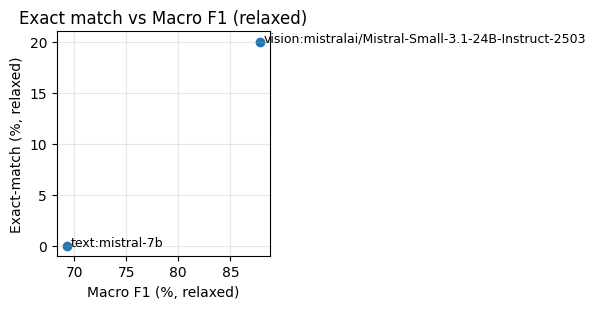

In [25]:
# --- cell: scatter macro-F1 vs exact-match ---

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.2))
plt.scatter(per_model["macro_f1"]*100, per_model["exact_match"]*100)
for _, r in per_model.iterrows():
    plt.text(r["macro_f1"]*100+0.4, r["exact_match"]*100, r["llm_model"], fontsize=9)
plt.xlabel("Macro F1 (%, relaxed)")
plt.ylabel("Exact-match (%, relaxed)")
plt.title("Exact match vs Macro F1 (relaxed)")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()


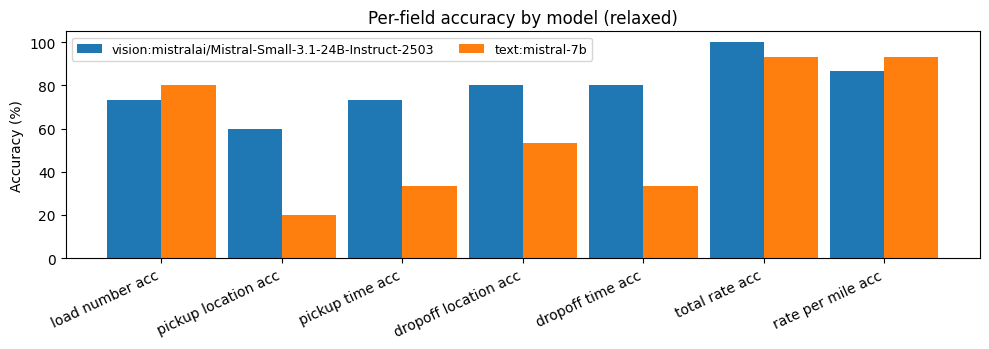

In [26]:
# --- cell: per-field accuracy bars ---

field_acc_cols = [f"{f}_acc" for f in TARGET_FIELDS]
acc_plot = per_model[["llm_model"] + field_acc_cols].set_index("llm_model")

plt.figure(figsize=(10,3.6))
x = np.arange(len(acc_plot.columns))
w = 0.9/len(acc_plot.index)  # thin bars per model

for i, (model, row) in enumerate(acc_plot.iterrows()):
    plt.bar(x + i*w, row.values*100, width=w, label=model)

plt.xticks(x + (len(acc_plot.index)-1)*w/2, [f.replace("_"," ") for f in acc_plot.columns], rotation=25, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Per-field accuracy by model (relaxed)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


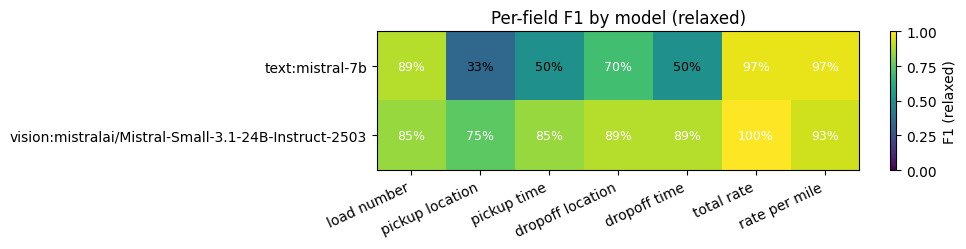

In [27]:
# --- cell: per-field F1 heatmap ---

# build per-model per-field F1 again from df
def prec_rec_f1(tp, fp, fn):
    p = tp/(tp+fp) if (tp+fp) else 0.0
    r = tp/(tp+fn) if (tp+fn) else 0.0
    f1 = 2*p*r/(p+r) if (p+r) else 0.0
    return p, r, f1

f1_rows = []
for model, g in df.groupby("llm_model"):
    row = {"llm_model": model}
    for f in TARGET_FIELDS:
        tp = int(g[f"{f}_correct"].sum())
        fp = int(((g[f] != "") & (~g[f"{f}_correct"])).sum())
        fn = int(((g[f"{f}_gold"] != "") & (g[f] == "")).sum())
        _, _, f1 = prec_rec_f1(tp, fp, fn)
        row[f] = f1
    f1_rows.append(row)

f1_df = pd.DataFrame(f1_rows).set_index("llm_model")

plt.figure(figsize=(10,2.6))
im = plt.imshow(f1_df.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, label="F1 (relaxed)")
plt.yticks(range(len(f1_df.index)), f1_df.index)
plt.xticks(range(len(TARGET_FIELDS)), [f.replace("_"," ") for f in TARGET_FIELDS], rotation=25, ha="right")
for i in range(f1_df.shape[0]):
    for j in range(f1_df.shape[1]):
        val = f1_df.iloc[i,j]
        plt.text(j, i, f"{int(round(val*100))}%", ha="center", va="center",
                 color="white" if val>0.55 else "black", fontsize=9)
plt.title("Per-field F1 by model (relaxed)")
plt.tight_layout()
plt.show()


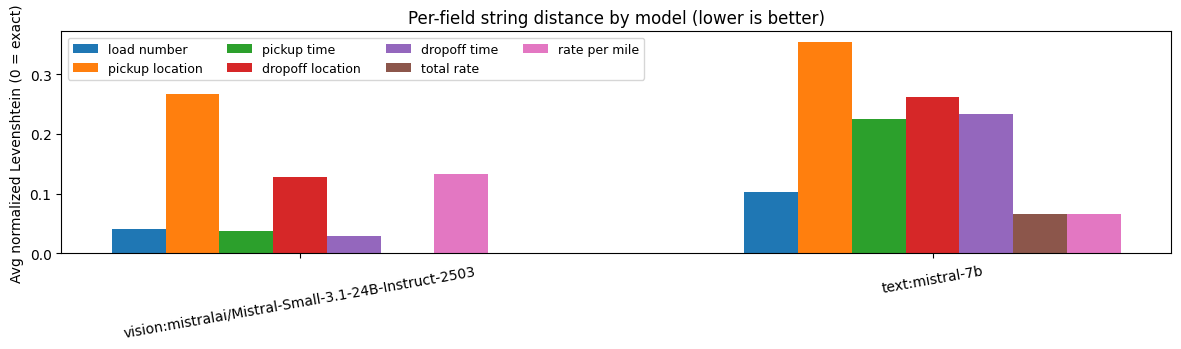

In [28]:
# --- cell: per-field normalized Levenshtein bars ---

plt.figure(figsize=(12,3.6))
x = np.arange(len(lev_df["llm_model"]))
width = 0.085

for k, f in enumerate(TARGET_FIELDS):
    plt.bar(x + (k - (len(TARGET_FIELDS)-1)/2)*width,
            lev_df[f"{f}_lev_mean"],
            width,
            label=f.replace("_"," "))

plt.xticks(x, lev_df["llm_model"], rotation=10)
plt.ylabel("Avg normalized Levenshtein (0 = exact)")
plt.title("Per-field string distance by model (lower is better)")
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()
